In [1]:
%load_ext autoreload
%autoreload 2

from src.dynamical_systems import *
from src.SINDyModel import *
from src.ESINDyModel import *
from src.derivatives import *
from src.helpers import *

import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
rhs = generate_lotka_volterra_rhs(*default_params['lotka_volterra'])
x0 = default_x0['lotka_volterra']
# rhs = generate_van_der_pol_oscillator_rhs(*default_params['van_der_pol_oscillator'])
# x0 = default_x0['van_der_pol_oscillator']

dt = 0.01
t_span = (0, 50)

t_eval = np.arange(t_span[0], t_span[1] + dt, dt)

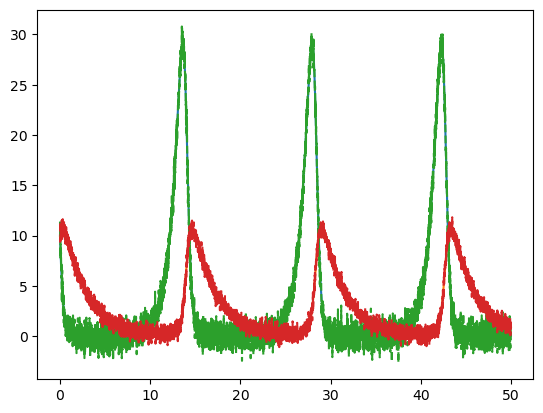

In [3]:
x_train = generate_training_data(rhs, x0, t_eval)

x_train_noisy = add_noise_to_data(x_train, 0.1)

plt.plot(t_eval, x_train.T)
plt.plot(t_eval, x_train_noisy.T, '--')
plt.show()

In [4]:
x_dot_true = rhs(t_eval, x_train)

window_diameters = np.arange(3, 200, 10)

dxdt_mse = np.zeros(len(window_diameters))

for i in tqdm(range(len(window_diameters))):
    x_dot_poly = dxdt_poly_fit(x_train_noisy, t_eval, 3, window_diameters[i])
    dxdt_mse[i] = np.mean((x_dot_true - x_dot_poly)**2)

100%|██████████| 20/20 [00:47<00:00,  2.36s/it]


In [5]:
x_dot_fd = dxdt_finite_difference(x_train_noisy, t_eval)
dxdt_fd_mse = np.mean((x_dot_true - x_dot_fd)**2)

Best window diameter: 63


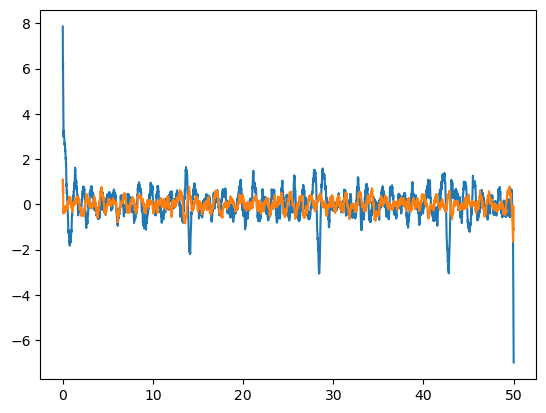

In [6]:
best_window_diameter = window_diameters[np.argmin(dxdt_mse)]
print(f'Best window diameter: {best_window_diameter}')

x_dot_poly = dxdt_poly_fit(x_train_noisy, t_eval, 3, best_window_diameter)

# plt.plot(t_eval, 0.1*x_train_noisy.T)
plt.plot(t_eval, x_dot_true.T - x_dot_poly.T)

# np.mean(x_dot_true - x_dot_poly, axis=1), np.mean(x_dot_true - x_dot_fd, axis=1)

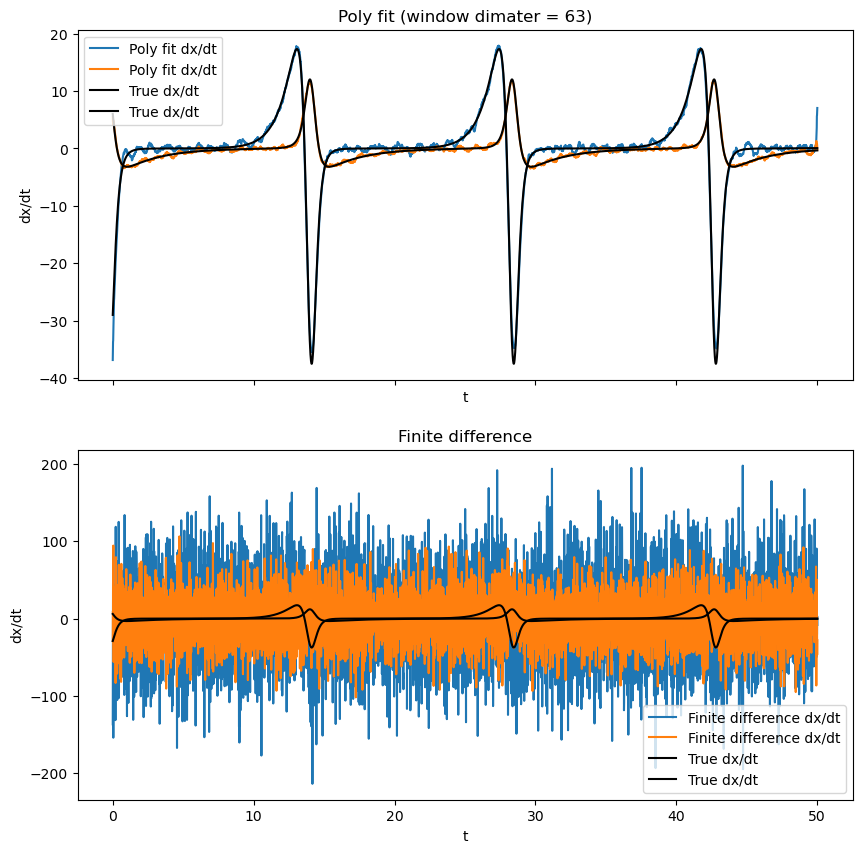

In [7]:
fig, axs = plt.subplots(nrows=2, ncols=1, sharex=True, figsize=(10, 10))

axs[0].plot(t_eval, x_dot_poly.T, label='Poly fit dx/dt')
axs[0].plot(t_eval, x_dot_true.T, 'k', label='True dx/dt')
axs[0].set_title('Poly fit (window dimater = 63)')
axs[0].set_ylabel('dx/dt')
axs[0].set_xlabel('t')
axs[0].legend()

axs[1].plot(t_eval, x_dot_fd.T, label='Finite difference dx/dt')
axs[1].plot(t_eval, x_dot_true.T, 'k', label='True dx/dt')
axs[1].set_title('Finite difference')
axs[1].set_ylabel('dx/dt')
axs[1].set_xlabel('t')
axs[1].legend()

plt.show()

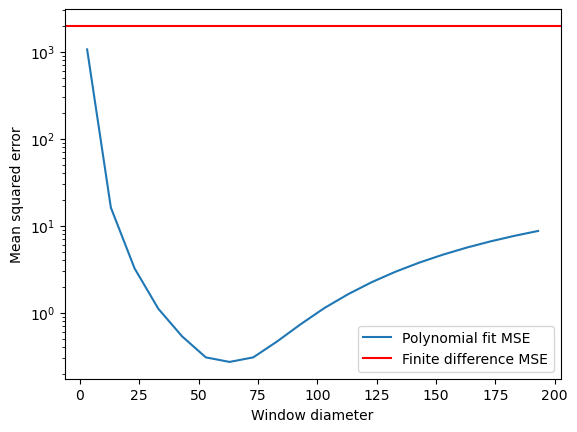

In [8]:
plt.semilogy(window_diameters, dxdt_mse, label='Polynomial fit MSE')
plt.axhline(dxdt_fd_mse, color='r', label='Finite difference MSE')
plt.xlabel('Window diameter')
plt.ylabel('Mean squared error')
plt.legend()

In [9]:
noise_levels = np.logspace(-3, 0, 20)

fd_models = []
poly_models = []
for noise_level in tqdm(noise_levels):
    x_train_noisy = add_noise_to_data(x_train, noise_level)

    x_dot_fd = dxdt_finite_difference(x_train_noisy, t_eval)
    model = ESINDyModel(n_state_vars=2, threshold=0.05, poly_order=5, use_ridge=True)
    model.fit(x_train_noisy, x_dot_fd)
    fd_models.append(model)

    x_dot_poly = dxdt_poly_fit(x_train_noisy, t_eval, 3, best_window_diameter)
    model = ESINDyModel(n_state_vars=2, threshold=0.05, poly_order=5, use_ridge=True)
    model.fit(x_train_noisy, x_dot_poly)
    poly_models.append(model)

100%|██████████| 20/20 [02:43<00:00,  8.16s/it]


In [10]:
noise_levels

array([0.001     , 0.00143845, 0.00206914, 0.00297635, 0.00428133,
       0.00615848, 0.00885867, 0.01274275, 0.01832981, 0.02636651,
       0.0379269 , 0.05455595, 0.078476  , 0.11288379, 0.16237767,
       0.23357215, 0.33598183, 0.48329302, 0.6951928 , 1.        ])

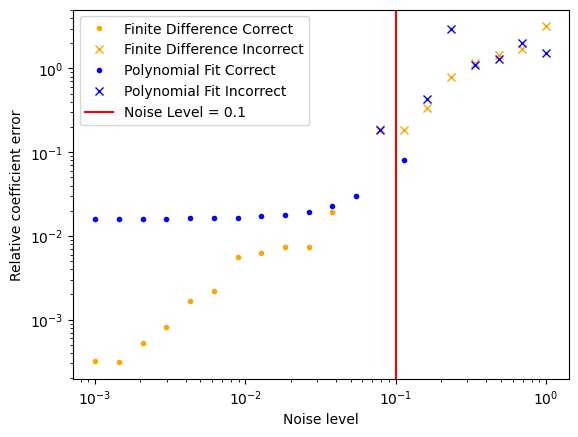

In [11]:
true_coeffs = generate_lotka_volterra_true_coefficients(*default_params['lotka_volterra'])

fd_rce = np.array([relative_coefficient_error(true_coeffs, model.Xi) for model in fd_models])
poly_rce = np.array([relative_coefficient_error(true_coeffs, model.Xi) for model in poly_models])

fd_correct = np.array([np.array_equal(np.nonzero(model.Xi), np.nonzero(true_coeffs)) for model in fd_models])
poly_correct = np.array([np.array_equal(np.nonzero(model.Xi), np.nonzero(true_coeffs)) for model in poly_models])


plt.loglog(noise_levels[fd_correct], fd_rce[fd_correct], '.', color='orange', label='Finite Difference Correct')
plt.loglog(noise_levels[~fd_correct], fd_rce[~fd_correct], 'x', color='orange', label='Finite Difference Incorrect')
plt.loglog(noise_levels[poly_correct], poly_rce[poly_correct], '.', color='blue', label='Polynomial Fit Correct')
plt.loglog(noise_levels[~poly_correct], poly_rce[~poly_correct], 'x', color='blue', label='Polynomial Fit Incorrect')
plt.axvline(0.1, color='r', label='Noise Level = 0.1')
plt.xlabel('Noise level')
plt.ylabel('Relative coefficient error')
plt.legend()
plt.show()